In [1]:
import torch
import cv2
import numpy as np
import os
import glob
from ultralytics import YOLO
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Define model paths for each class
model_paths = {
    0: "/home/kwdahun/2025IMSC-Hackathon-CRACKPINK/saved_checkpoints/pothole_best_plz.pt",      # Pothole
    1: "/home/kwdahun/2025IMSC-Hackathon-CRACKPINK/cls_yolo_runs/class_13/weights/best.pt",     # Alligator Crack
    2: "/home/kwdahun/2025IMSC-Hackathon-CRACKPINK/cls_yolo_runs/class_22/weights/best.pt",     # Transverse Crack
    3: "/home/kwdahun/2025IMSC-Hackathon-CRACKPINK/cls_yolo_runs/class_32/weights/best.pt"      # Longitudinal Crack
}

# Class names
class_names = {
    0: "Pothole",
    1: "Alligator Crack", 
    2: "Transverse Crack",
    3: "Longitudinal Crack"
}

# Dataset paths
test_images_path = "/home/kwdahun/2025IMSC-Hackathon-CRACKPINK/yolo_dataset/test/images"
test_labels_path = "/home/kwdahun/2025IMSC-Hackathon-CRACKPINK/yolo_dataset/test/labels"

print("Model paths:")
for class_id, path in model_paths.items():
    print(f"Class {class_id} ({class_names[class_id]}): {path}")
    print(f"  Model exists: {os.path.exists(path)}")
print()
print(f"Test images path: {test_images_path}")
print(f"Test labels path: {test_labels_path}")
print(f"Images exist: {os.path.exists(test_images_path)}")
print(f"Labels exist: {os.path.exists(test_labels_path)}")

Model paths:
Class 0 (Pothole): /home/kwdahun/2025IMSC-Hackathon-CRACKPINK/cls_yolo_runs/pothole/weights/best.pt
  Model exists: True
Class 1 (Alligator Crack): /home/kwdahun/2025IMSC-Hackathon-CRACKPINK/cls_yolo_runs/class_13/weights/best.pt
  Model exists: True
Class 2 (Transverse Crack): /home/kwdahun/2025IMSC-Hackathon-CRACKPINK/cls_yolo_runs/class_22/weights/best.pt
  Model exists: True
Class 3 (Longitudinal Crack): /home/kwdahun/2025IMSC-Hackathon-CRACKPINK/cls_yolo_runs/class_32/weights/best.pt
  Model exists: True

Test images path: /home/kwdahun/2025IMSC-Hackathon-CRACKPINK/yolo_dataset/test/images
Test labels path: /home/kwdahun/2025IMSC-Hackathon-CRACKPINK/yolo_dataset/test/labels
Images exist: True
Labels exist: True


In [3]:
# Load all models
models = {}
print("Loading models...")
for class_id, model_path in model_paths.items():
    if os.path.exists(model_path):
        try:
            models[class_id] = YOLO(model_path)
            print(f"✓ Loaded model for class {class_id} ({class_names[class_id]})")
        except Exception as e:
            print(f"✗ Failed to load model for class {class_id}: {e}")
    else:
        print(f"✗ Model file not found for class {class_id}: {model_path}")

print(f"\nSuccessfully loaded {len(models)} models out of {len(model_paths)}")

Loading models...
✓ Loaded model for class 0 (Pothole)
✓ Loaded model for class 1 (Alligator Crack)
✓ Loaded model for class 2 (Transverse Crack)
✓ Loaded model for class 3 (Longitudinal Crack)

Successfully loaded 4 models out of 4


In [4]:
def parse_yolo_label(label_path):
    """Parse YOLO format label file and return list of (class_id, bbox) tuples"""
    if not os.path.exists(label_path):
        return []
    
    annotations = []
    with open(label_path, 'r') as f:
        for line in f.readlines():
            line = line.strip()
            if line:
                parts = line.split()
                class_id = int(parts[0])
                x_center, y_center, width, height = map(float, parts[1:5])
                annotations.append((class_id, [x_center, y_center, width, height]))
    return annotations

def ensemble_predict(image_path, models, confidence_threshold=0.25, iou_threshold=0.45):
    """
    Perform ensemble prediction using all class-specific models
    Returns combined predictions with NMS applied
    """
    # Read image
    image = cv2.imread(image_path)
    if image is None:
        return []
    
    all_predictions = []
    
    # Get predictions from each model
    for class_id, model in models.items():
        try:
            results = model(image_path, conf=confidence_threshold, iou=iou_threshold, verbose=False)
            
            for result in results:
                if result.boxes is not None and len(result.boxes) > 0:
                    boxes = result.boxes.xyxy.cpu().numpy()  # x1, y1, x2, y2
                    confidences = result.boxes.conf.cpu().numpy()
                    
                    # Convert to normalized coordinates (YOLO format)
                    img_h, img_w = image.shape[:2]
                    
                    for box, conf in zip(boxes, confidences):
                        x1, y1, x2, y2 = box
                        
                        # Convert to YOLO format (center_x, center_y, width, height) normalized
                        center_x = (x1 + x2) / 2 / img_w
                        center_y = (y1 + y2) / 2 / img_h
                        width = (x2 - x1) / img_w
                        height = (y2 - y1) / img_h
                        
                        all_predictions.append({
                            'class_id': class_id,
                            'confidence': conf,
                            'bbox': [center_x, center_y, width, height],
                            'bbox_xyxy': [x1, y1, x2, y2]
                        })
                        
        except Exception as e:
            print(f"Error predicting with model {class_id}: {e}")
            continue
    
    return all_predictions

def calculate_iou(box1, box2):
    """Calculate IoU between two bounding boxes in xyxy format"""
    x1_1, y1_1, x2_1, y2_1 = box1
    x1_2, y1_2, x2_2, y2_2 = box2
    
    # Calculate intersection
    x1_i = max(x1_1, x1_2)
    y1_i = max(y1_1, y1_2)
    x2_i = min(x2_1, x2_2)
    y2_i = min(y2_1, y2_2)
    
    if x2_i <= x1_i or y2_i <= y1_i:
        return 0.0
    
    intersection = (x2_i - x1_i) * (y2_i - y1_i)
    
    # Calculate union
    area1 = (x2_1 - x1_1) * (y2_1 - y1_1)
    area2 = (x2_2 - x1_2) * (y2_2 - y1_2)
    union = area1 + area2 - intersection
    
    return intersection / union if union > 0 else 0.0

def yolo_to_xyxy(bbox, img_w, img_h):
    """Convert YOLO format (normalized) to xyxy format"""
    center_x, center_y, width, height = bbox
    x1 = (center_x - width/2) * img_w
    y1 = (center_y - height/2) * img_h
    x2 = (center_x + width/2) * img_w
    y2 = (center_y + height/2) * img_h
    return [x1, y1, x2, y2]

In [5]:
# Get all test images
test_images = glob.glob(os.path.join(test_images_path, "*.jpg"))
print(f"Found {len(test_images)} test images")

# Initialize evaluation metrics
all_predictions = []
all_ground_truths = []
detailed_results = []

print("Starting ensemble evaluation...")

# Process each test image
for i, image_path in enumerate(tqdm(test_images, desc="Processing images")):
    image_name = os.path.basename(image_path)
    label_path = os.path.join(test_labels_path, image_name.replace('.jpg', '.txt'))
    
    # Get ground truth
    gt_annotations = parse_yolo_label(label_path)
    
    # Get ensemble predictions
    predictions = ensemble_predict(image_path, models, confidence_threshold=0.25, iou_threshold=0.45)
    
    # Read image dimensions for coordinate conversion
    image = cv2.imread(image_path)
    img_h, img_w = image.shape[:2]
    
    # Convert ground truth to xyxy format for IoU calculation
    gt_boxes_xyxy = []
    gt_classes = []
    for gt_class, gt_bbox in gt_annotations:
        gt_box_xyxy = yolo_to_xyxy(gt_bbox, img_w, img_h)
        gt_boxes_xyxy.append(gt_box_xyxy)
        gt_classes.append(gt_class)
    
    # Match predictions to ground truth using IoU threshold
    iou_threshold = 0.5
    used_gt_indices = set()
    
    tp_per_class = defaultdict(int)
    fp_per_class = defaultdict(int)
    
    # Sort predictions by confidence (highest first)
    predictions.sort(key=lambda x: x['confidence'], reverse=True)
    
    for pred in predictions:
        pred_class = pred['class_id']
        pred_box_xyxy = pred['bbox_xyxy']
        
        best_iou = 0
        best_gt_idx = -1
        
        # Find best matching ground truth
        for gt_idx, (gt_class, gt_box_xyxy) in enumerate(zip(gt_classes, gt_boxes_xyxy)):
            if gt_idx in used_gt_indices:
                continue
                
            if gt_class == pred_class:
                iou = calculate_iou(pred_box_xyxy, gt_box_xyxy)
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = gt_idx
        
        # Determine if prediction is TP or FP
        if best_iou >= iou_threshold and best_gt_idx != -1:
            tp_per_class[pred_class] += 1
            used_gt_indices.add(best_gt_idx)
        else:
            fp_per_class[pred_class] += 1
    
    # Count false negatives (ground truth not matched)
    fn_per_class = defaultdict(int)
    for gt_idx, gt_class in enumerate(gt_classes):
        if gt_idx not in used_gt_indices:
            fn_per_class[gt_class] += 1
    
    # Store results
    result = {
        'image': image_name,
        'gt_count': len(gt_annotations),
        'pred_count': len(predictions),
        'tp_per_class': dict(tp_per_class),
        'fp_per_class': dict(fp_per_class),
        'fn_per_class': dict(fn_per_class)
    }
    detailed_results.append(result)

print("Evaluation completed!")

Found 906 test images
Starting ensemble evaluation...


Processing images: 100%|██████████| 906/906 [00:48<00:00, 18.67it/s]

Evaluation completed!


In [6]:
# Calculate overall metrics per class
overall_metrics = {}

for class_id in range(4):
    tp = sum(result['tp_per_class'].get(class_id, 0) for result in detailed_results)
    fp = sum(result['fp_per_class'].get(class_id, 0) for result in detailed_results)
    fn = sum(result['fn_per_class'].get(class_id, 0) for result in detailed_results)
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    overall_metrics[class_id] = {
        'class_name': class_names[class_id],
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }

# Display results
print("="*80)
print("ENSEMBLE MODEL EVALUATION RESULTS")
print("="*80)
print()

# Per-class metrics
df_metrics = pd.DataFrame(overall_metrics).T
print("Per-Class Metrics:")
print(df_metrics[['class_name', 'tp', 'fp', 'fn', 'precision', 'recall', 'f1_score']].round(4))
print()

# Overall metrics
total_tp = sum(metrics['tp'] for metrics in overall_metrics.values())
total_fp = sum(metrics['fp'] for metrics in overall_metrics.values())
total_fn = sum(metrics['fn'] for metrics in overall_metrics.values())

macro_precision = np.mean([metrics['precision'] for metrics in overall_metrics.values()])
macro_recall = np.mean([metrics['recall'] for metrics in overall_metrics.values()])
macro_f1 = np.mean([metrics['f1_score'] for metrics in overall_metrics.values()])

micro_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
micro_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
micro_f1 = 2 * (micro_precision * micro_recall) / (micro_precision + micro_recall) if (micro_precision + micro_recall) > 0 else 0

print("Overall Metrics:")
print(f"Macro-averaged Precision: {macro_precision:.4f}")
print(f"Macro-averaged Recall:    {macro_recall:.4f}")
print(f"Macro-averaged F1-score:  {macro_f1:.4f}")
print()
print(f"Micro-averaged Precision: {micro_precision:.4f}")
print(f"Micro-averaged Recall:    {micro_recall:.4f}")
print(f"Micro-averaged F1-score:  {micro_f1:.4f}")
print()
print(f"Total True Positives:  {total_tp}")
print(f"Total False Positives: {total_fp}")
print(f"Total False Negatives: {total_fn}")

ENSEMBLE MODEL EVALUATION RESULTS

Per-Class Metrics:
           class_name   tp   fp   fn precision    recall  f1_score
0             Pothole  472  306   58  0.606684  0.890566  0.721713
1     Alligator Crack  424  400  107  0.514563  0.798493   0.62583
2    Transverse Crack  518  325  150  0.614472  0.775449  0.685639
3  Longitudinal Crack  580  458  182  0.558767  0.761155  0.644444

Overall Metrics:
Macro-averaged Precision: 0.5736
Macro-averaged Recall:    0.8064
Macro-averaged F1-score:  0.6694

Micro-averaged Precision: 0.5725
Micro-averaged Recall:    0.8005
Micro-averaged F1-score:  0.6676

Total True Positives:  1994
Total False Positives: 1489
Total False Negatives: 497


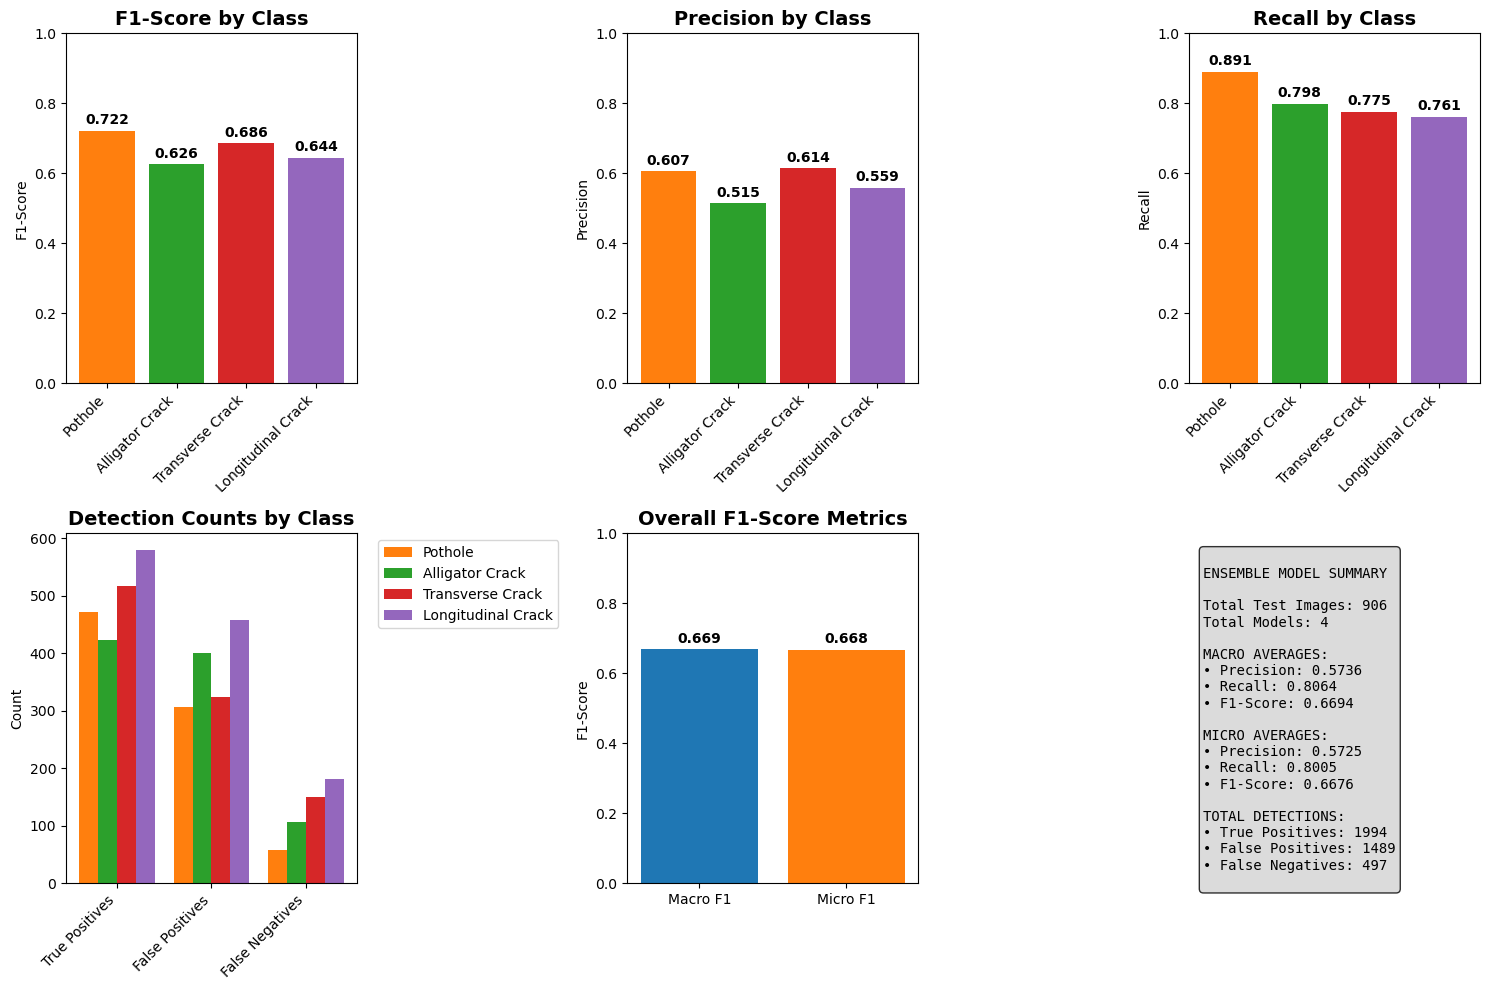


DETAILED METRICS TABLE
             Class  Precision  Recall  F1-Score  True Positives  False Positives  False Negatives
           Pothole     0.6067  0.8906    0.7217             472              306               58
   Alligator Crack     0.5146  0.7985    0.6258             424              400              107
  Transverse Crack     0.6145  0.7754    0.6856             518              325              150
Longitudinal Crack     0.5588  0.7612    0.6444             580              458              182

Macro-averaged F1-Score: 0.6694
Micro-averaged F1-Score: 0.6676


In [7]:
# Create visualizations
plt.figure(figsize=(15, 10))

# 1. F1-score comparison
plt.subplot(2, 3, 1)
classes = [class_names[i] for i in range(4)]
f1_scores = [overall_metrics[i]['f1_score'] for i in range(4)]
bars = plt.bar(classes, f1_scores, color=['#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
plt.title('F1-Score by Class', fontsize=14, fontweight='bold')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

# 2. Precision comparison
plt.subplot(2, 3, 2)
precisions = [overall_metrics[i]['precision'] for i in range(4)]
bars = plt.bar(classes, precisions, color=['#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
plt.title('Precision by Class', fontsize=14, fontweight='bold')
plt.ylabel('Precision')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

# 3. Recall comparison
plt.subplot(2, 3, 3)
recalls = [overall_metrics[i]['recall'] for i in range(4)]
bars = plt.bar(classes, recalls, color=['#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
plt.title('Recall by Class', fontsize=14, fontweight='bold')
plt.ylabel('Recall')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

# 4. Confusion Matrix-like visualization (TP, FP, FN)
plt.subplot(2, 3, 4)
categories = ['True Positives', 'False Positives', 'False Negatives']
class_0_data = [overall_metrics[0]['tp'], overall_metrics[0]['fp'], overall_metrics[0]['fn']]
class_1_data = [overall_metrics[1]['tp'], overall_metrics[1]['fp'], overall_metrics[1]['fn']]
class_2_data = [overall_metrics[2]['tp'], overall_metrics[2]['fp'], overall_metrics[2]['fn']]
class_3_data = [overall_metrics[3]['tp'], overall_metrics[3]['fp'], overall_metrics[3]['fn']]

x = np.arange(len(categories))
width = 0.2

plt.bar(x - 1.5*width, class_0_data, width, label=class_names[0], color='#ff7f0e')
plt.bar(x - 0.5*width, class_1_data, width, label=class_names[1], color='#2ca02c')
plt.bar(x + 0.5*width, class_2_data, width, label=class_names[2], color='#d62728')
plt.bar(x + 1.5*width, class_3_data, width, label=class_names[3], color='#9467bd')

plt.title('Detection Counts by Class', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.xticks(x, categories, rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 5. Overall metrics comparison
plt.subplot(2, 3, 5)
overall_names = ['Macro F1', 'Micro F1']
overall_values = [macro_f1, micro_f1]
bars = plt.bar(overall_names, overall_values, color=['#1f77b4', '#ff7f0e'])
plt.title('Overall F1-Score Metrics', fontsize=14, fontweight='bold')
plt.ylabel('F1-Score')
plt.ylim(0, 1)
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

# 6. Model performance summary
plt.subplot(2, 3, 6)
plt.axis('off')
summary_text = f"""
ENSEMBLE MODEL SUMMARY

Total Test Images: {len(test_images)}
Total Models: {len(models)}

MACRO AVERAGES:
• Precision: {macro_precision:.4f}
• Recall: {macro_recall:.4f}
• F1-Score: {macro_f1:.4f}

MICRO AVERAGES:
• Precision: {micro_precision:.4f}
• Recall: {micro_recall:.4f}
• F1-Score: {micro_f1:.4f}

TOTAL DETECTIONS:
• True Positives: {total_tp}
• False Positives: {total_fp}
• False Negatives: {total_fn}
"""
plt.text(0.05, 0.95, summary_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*80)
print("DETAILED METRICS TABLE")
print("="*80)
summary_df = pd.DataFrame({
    'Class': [class_names[i] for i in range(4)],
    'Precision': [overall_metrics[i]['precision'] for i in range(4)],
    'Recall': [overall_metrics[i]['recall'] for i in range(4)],
    'F1-Score': [overall_metrics[i]['f1_score'] for i in range(4)],
    'True Positives': [overall_metrics[i]['tp'] for i in range(4)],
    'False Positives': [overall_metrics[i]['fp'] for i in range(4)],
    'False Negatives': [overall_metrics[i]['fn'] for i in range(4)]
})

print(summary_df.round(4).to_string(index=False))
print(f"\nMacro-averaged F1-Score: {macro_f1:.4f}")
print(f"Micro-averaged F1-Score: {micro_f1:.4f}")

In [8]:
# Save results to CSV files
results_dir = "/home/kwdahun/2025IMSC-Hackathon-CRACKPINK/ensemble_results"
os.makedirs(results_dir, exist_ok=True)

# Save summary metrics
summary_df.to_csv(os.path.join(results_dir, "ensemble_class_metrics.csv"), index=False)

# Save overall metrics
overall_metrics_df = pd.DataFrame({
    'Metric': ['Macro Precision', 'Macro Recall', 'Macro F1-Score', 
               'Micro Precision', 'Micro Recall', 'Micro F1-Score'],
    'Value': [macro_precision, macro_recall, macro_f1,
              micro_precision, micro_recall, micro_f1]
})
overall_metrics_df.to_csv(os.path.join(results_dir, "ensemble_overall_metrics.csv"), index=False)

# Save detailed results per image
detailed_df = pd.DataFrame(detailed_results)
detailed_df.to_csv(os.path.join(results_dir, "ensemble_detailed_results.csv"), index=False)

print(f"Results saved to: {results_dir}")
print("Files created:")
print("- ensemble_class_metrics.csv")
print("- ensemble_overall_metrics.csv") 
print("- ensemble_detailed_results.csv")

# Final summary
print("\n" + "="*80)
print("ENSEMBLE EVALUATION COMPLETE")
print("="*80)
print(f"🎯 Best performing class: {max(overall_metrics.items(), key=lambda x: x[1]['f1_score'])[1]['class_name']}")
print(f"📊 Macro F1-Score: {macro_f1:.4f}")
print(f"📊 Micro F1-Score: {micro_f1:.4f}")
print(f"🔍 Total test images processed: {len(test_images)}")
print(f"🤖 Models used in ensemble: {len(models)}")
print("="*80)

Results saved to: /home/kwdahun/2025IMSC-Hackathon-CRACKPINK/ensemble_results
Files created:
- ensemble_class_metrics.csv
- ensemble_overall_metrics.csv
- ensemble_detailed_results.csv

ENSEMBLE EVALUATION COMPLETE
🎯 Best performing class: Pothole
📊 Macro F1-Score: 0.6694
📊 Micro F1-Score: 0.6676
🔍 Total test images processed: 906
🤖 Models used in ensemble: 4


In [9]:
# Add evaluation method to generate inference results like test_evaluation.ipynb
def run_ensemble_inference_and_save(image_path, models, confidence_threshold=0.10):
    """
    Run ensemble inference on a single image and save the result as txt file in YOLO format with confidence
    Format: <class(0-3)> <x_center_normalized> <y_center_normalized> <width_normalized> <height_normalized> <confidence>
    """
    # Read image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error reading image: {image_path}")
        return None
    
    img_height, img_width = image.shape[:2]
    filename = os.path.basename(image_path)
    
    # Get ensemble predictions
    all_predictions = ensemble_predict(image_path, models, confidence_threshold=confidence_threshold, iou_threshold=0.45)
    
    # Prepare output txt file path (same name as image but with .txt extension)
    txt_filename = os.path.splitext(filename)[0] + '.txt'
    output_txt_path = os.path.join("/home/kwdahun/2025IMSC-Hackathon-CRACKPINK/inference_result", txt_filename)
    
    detections = []
    
    # Open txt file for writing
    with open(output_txt_path, 'w') as f:
        if len(all_predictions) > 0:
            for pred in all_predictions:
                class_id = pred['class_id']
                confidence = pred['confidence']
                bbox = pred['bbox']  # Already in normalized format [center_x, center_y, width, height]
                
                x_center_norm, y_center_norm, width_norm, height_norm = bbox
                
                # Store detection info
                detections.append({
                    'class_id': class_id,
                    'class_name': class_names[class_id],
                    'confidence': float(confidence),
                    'x_center_norm': x_center_norm,
                    'y_center_norm': y_center_norm,
                    'width_norm': width_norm,
                    'height_norm': height_norm
                })
                
                # Write to txt file in the specified format
                f.write(f"{class_id} {x_center_norm:.6f} {y_center_norm:.6f} {width_norm:.6f} {height_norm:.6f} {confidence:.6f}\n")
    
    return {
        'image_path': image_path,
        'output_path': output_txt_path,
        'detections': detections,
        'num_detections': len(detections)
    }

print("Ensemble inference function defined successfully!")
print("Output format: <class(0-3)> <x_center_normalized> <y_center_normalized> <width_normalized> <height_normalized> <confidence>")

Ensemble inference function defined successfully!
Output format: <class(0-3)> <x_center_normalized> <y_center_normalized> <width_normalized> <height_normalized> <confidence>


In [ ]:
# Function to collect all test images from test_data directory (like test_evaluation.ipynb)
def get_all_test_images_for_inference():
    """Collect all test images from all countries in test_data directory"""
    TEST_DATA_DIR = "/home/kwdahun/2025IMSC-Hackathon-CRACKPINK/test_data"
    all_images = []
    
    for country in ['country_1', 'country_2', 'country_3']:
        country_path = os.path.join(TEST_DATA_DIR, country, 'images')
        if os.path.exists(country_path):
            image_files = glob.glob(os.path.join(country_path, '*.jpg'))
            for img_path in image_files:
                all_images.append({
                    'path': img_path,
                    'country': country,
                    'filename': os.path.basename(img_path)
                })
    
    return all_images

# Create inference_result directory
INFERENCE_OUTPUT_DIR = "/home/kwdahun/2025IMSC-Hackathon-CRACKPINK/inference_result"
os.makedirs(INFERENCE_OUTPUT_DIR, exist_ok=True)
print(f"Created/verified inference output directory: {INFERENCE_OUTPUT_DIR}")

# Get all test images for inference
test_images_for_inference = get_all_test_images_for_inference()
print(f"Total test images found for inference: {len(test_images_for_inference)}")

# Show distribution by country
for country in ['country_1', 'country_2', 'country_3']:
    country_count = len([img for img in test_images_for_inference if img['country'] == country])
    print(f"{country}: {country_count} images")

Created/verified inference output directory: /home/kwdahun/2025IMSC-Hackathon-CRACKPINK/inference_result
Total test images found for inference: 2961
country_1: 1024 images
country_2: 918 images
country_3: 1019 images


In [11]:
# Run ensemble inference on all test images and save results
print("Starting ensemble inference on all test images...")
print(f"Processing {len(test_images_for_inference)} images...")

ensemble_inference_results = []
failed_inference_images = []

# Set confidence threshold for inference (same as test_evaluation.ipynb)
INFERENCE_CONFIDENCE_THRESHOLD = 0.10

print(f"Using confidence threshold: {INFERENCE_CONFIDENCE_THRESHOLD}")
print(f"Output directory: {INFERENCE_OUTPUT_DIR}")
print("Output format: <class(0-3)> <x_center_normalized> <y_center_normalized> <width_normalized> <height_normalized> <confidence>")

# Process images with progress bar
for i, image_info in enumerate(tqdm(test_images_for_inference, desc="Running ensemble inference")):
    try:
        result = run_ensemble_inference_and_save(image_info['path'], models, INFERENCE_CONFIDENCE_THRESHOLD)
        if result is not None:
            ensemble_inference_results.append(result)
        else:
            failed_inference_images.append(image_info['path'])
    except Exception as e:
        print(f"Error processing {image_info['path']}: {str(e)}")
        failed_inference_images.append(image_info['path'])

print(f"\nEnsemble inference completed!")
print(f"Successfully processed: {len(ensemble_inference_results)} images")
print(f"Failed to process: {len(failed_inference_images)} images")

# Summary statistics
total_detections = sum(result['num_detections'] for result in ensemble_inference_results)
avg_detections_per_image = total_detections / len(ensemble_inference_results) if ensemble_inference_results else 0

print(f"\nInference Summary:")
print(f"Total detections across all images: {total_detections}")
print(f"Average detections per image: {avg_detections_per_image:.2f}")

# Count detections by class
class_detection_counts = {i: 0 for i in range(4)}
for result in ensemble_inference_results:
    for detection in result['detections']:
        class_detection_counts[detection['class_id']] += 1

print(f"\nDetections by class:")
for class_id, count in class_detection_counts.items():
    print(f"  {class_names[class_id]}: {count} detections")

# List some example output files
example_files = [result['output_path'] for result in ensemble_inference_results[:5]]
print(f"\nExample output files created:")
for file_path in example_files:
    if os.path.exists(file_path):
        print(f"  ✓ {file_path}")
    else:
        print(f"  ✗ {file_path}")

print(f"\nAll inference results saved to: {INFERENCE_OUTPUT_DIR}")
print("Format matches test_evaluation.ipynb: TXT files with same name as images (YOLO format with confidence)")

Starting ensemble inference on all test images...
Processing 2961 images...
Using confidence threshold: 0.1
Output directory: /home/kwdahun/2025IMSC-Hackathon-CRACKPINK/inference_result
Output format: <class(0-3)> <x_center_normalized> <y_center_normalized> <width_normalized> <height_normalized> <confidence>


Running ensemble inference: 100%|██████████| 2961/2961 [02:29<00:00, 19.81it/s]


Ensemble inference completed!
Successfully processed: 2961 images
Failed to process: 0 images

Inference Summary:
Total detections across all images: 17204
Average detections per image: 5.81

Detections by class:
  Pothole: 3618 detections
  Alligator Crack: 4432 detections
  Transverse Crack: 4169 detections
  Longitudinal Crack: 4985 detections

Example output files created:
  ✓ /home/kwdahun/2025IMSC-Hackathon-CRACKPINK/inference_result/country1_008643.txt
  ✓ /home/kwdahun/2025IMSC-Hackathon-CRACKPINK/inference_result/country1_002089.txt
  ✓ /home/kwdahun/2025IMSC-Hackathon-CRACKPINK/inference_result/country1_007890.txt
  ✓ /home/kwdahun/2025IMSC-Hackathon-CRACKPINK/inference_result/country1_007682.txt
  ✓ /home/kwdahun/2025IMSC-Hackathon-CRACKPINK/inference_result/country1_008386.txt

All inference results saved to: /home/kwdahun/2025IMSC-Hackathon-CRACKPINK/inference_result
Format matches test_evaluation.ipynb: TXT files with same name as images (YOLO format with confidence)


In [12]:
# Optional: Compare with existing inference results (if any)
existing_results_dir = "/home/kwdahun/2025IMSC-Hackathon-CRACKPINK/inference_result"
existing_txt_files = glob.glob(os.path.join(existing_results_dir, "*.txt"))

if len(existing_txt_files) > 0:
    print(f"\nFound {len(existing_txt_files)} existing result files in inference_result directory")
    
    # Sample a few files to show the format
    sample_files = existing_txt_files[:3]
    print("\nSample ensemble inference results:")
    
    for file_path in sample_files:
        filename = os.path.basename(file_path)
        print(f"\nFile: {filename}")
        try:
            with open(file_path, 'r') as f:
                lines = f.readlines()
                if lines:
                    print(f"  Number of detections: {len(lines)}")
                    print("  Sample detections:")
                    for i, line in enumerate(lines[:3]):  # Show first 3 detections
                        parts = line.strip().split()
                        if len(parts) >= 6:
                            class_id = int(parts[0])
                            confidence = float(parts[5])
                            print(f"    Detection {i+1}: Class {class_id} ({class_names[class_id]}) - Confidence: {confidence:.3f}")
                    if len(lines) > 3:
                        print(f"    ... and {len(lines)-3} more detections")
                else:
                    print("  No detections found")
        except Exception as e:
            print(f"  Error reading file: {e}")

print(f"\n" + "="*80)
print("ENSEMBLE INFERENCE COMPLETE")
print("="*80)
print(f"🎯 Total images processed: {len(ensemble_inference_results)}")
print(f"📁 Results saved to: {INFERENCE_OUTPUT_DIR}")
print(f"📊 Total detections: {total_detections}")
print(f"🤖 Ensemble models used: {len(models)}")
print(f"⚙️  Confidence threshold: {INFERENCE_CONFIDENCE_THRESHOLD}")
print(f"📝 Output format: YOLO format with confidence scores")
print("="*80)


Found 2961 existing result files in inference_result directory

Sample ensemble inference results:

File: country3_001614.txt
  Number of detections: 9
  Sample detections:
    Detection 1: Class 0 (Pothole) - Confidence: 0.338
    Detection 2: Class 2 (Transverse Crack) - Confidence: 0.860
    Detection 3: Class 2 (Transverse Crack) - Confidence: 0.750
    ... and 6 more detections

File: country2_007061.txt
  Number of detections: 4
  Sample detections:
    Detection 1: Class 0 (Pothole) - Confidence: 0.373
    Detection 2: Class 1 (Alligator Crack) - Confidence: 0.675
    Detection 3: Class 1 (Alligator Crack) - Confidence: 0.142
    ... and 1 more detections

File: country2_006275.txt
  Number of detections: 10
  Sample detections:
    Detection 1: Class 0 (Pothole) - Confidence: 0.309
    Detection 2: Class 0 (Pothole) - Confidence: 0.109
    Detection 3: Class 1 (Alligator Crack) - Confidence: 0.723
    ... and 7 more detections

ENSEMBLE INFERENCE COMPLETE
🎯 Total images proces